<a href="https://colab.research.google.com/github/shivampatle2004/Machine-Learning-/blob/main/Naive_bayes_shivam_cs23186_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Perform an analysis of the Breast Cancer dataset using the Gaussian Naive Bayes model. This involves loading the dataset, conducting basic data analysis, splitting the data into 70/30 and 80/20 train/test ratios, training the model on both splits, evaluating performance using accuracy, confusion matrix, and classification report, comparing results with visualizations, and drawing a conclusion on the optimal split ratio. Finally, provide the complete Google Colab Python code.

In [1]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load the Breast Cancer dataset
cancer = load_breast_cancer()

print("Libraries imported and Breast Cancer dataset loaded successfully.")

Libraries imported and Breast Cancer dataset loaded successfully.


## Convert to DataFrame and Basic Data Analysis



In [2]:
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target

print("Shape of the DataFrame:")
print(df.shape)
print("\n")

print("DataFrame Info:")
df.info()
print("\n")

print("Descriptive Statistics:")
print(df.describe())
print("\n")

print("Missing Values:")
print(df.isnull().sum())
print("\n")

print("Target Variable Class Distribution:")
print(df['target'].value_counts())


Shape of the DataFrame:
(569, 31)


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569

## Split Dataset for Training and Testing


Split the dataset into features (X) and target (y). Apply train-test split with two different ratios: 70% training / 30% testing and 80% training / 20% testing.


In [3]:
X = df.drop('target', axis=1)
y = df['target']

# Split 1: 70% training / 30% testing
X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(X, y, test_size=0.3, random_state=42)

# Split 2: 80% training / 20% testing
X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(X, y, test_size=0.2, random_state=42)

print("Dataset split into features (X) and target (y).")
print(f"Shape of X: {X.shape}, Shape of y: {y.shape}\n")

print("70/30 Split Shapes:")
print(f"X_train_70: {X_train_70.shape}, X_test_70: {X_test_70.shape}")
print(f"y_train_70: {y_train_70.shape}, y_test_70: {y_test_70.shape}\n")

print("80/20 Split Shapes:")
print(f"X_train_80: {X_train_80.shape}, X_test_80: {X_test_80.shape}")
print(f"y_train_80: {y_train_80.shape}, y_test_80: {y_test_80.shape}")

Dataset split into features (X) and target (y).
Shape of X: (569, 30), Shape of y: (569,)

70/30 Split Shapes:
X_train_70: (398, 30), X_test_70: (171, 30)
y_train_70: (398,), y_test_70: (171,)

80/20 Split Shapes:
X_train_80: (455, 30), X_test_80: (114, 30)
y_train_80: (455,), y_test_80: (114,)


In [4]:
model_70 = GaussianNB()
model_80 = GaussianNB()

# Train model on 70/30 split
model_70.fit(X_train_70, y_train_70)
print("Gaussian Naive Bayes model trained on 70/30 split.")

# Train model on 80/20 split
model_80.fit(X_train_80, y_train_80)
print("Gaussian Naive Bayes model trained on 80/20 split.")

Gaussian Naive Bayes model trained on 70/30 split.
Gaussian Naive Bayes model trained on 80/20 split.


## Model Evaluation
.



In [5]:
print("Evaluation for 70/30 Split:")
# Make predictions
y_pred_70 = model_70.predict(X_test_70)

# Calculate accuracy
accuracy_70 = accuracy_score(y_test_70, y_pred_70)
print(f"Accuracy: {accuracy_70:.4f}")

# Generate confusion matrix
conf_matrix_70 = confusion_matrix(y_test_70, y_pred_70)
print("Confusion Matrix:")
print(conf_matrix_70)

# Generate classification report
class_report_70 = classification_report(y_test_70, y_pred_70)
print("Classification Report:")
print(class_report_70)

print("\n" + "-"*30 + "\n")

print("Evaluation for 80/20 Split:")
# Make predictions
y_pred_80 = model_80.predict(X_test_80)

# Calculate accuracy
accuracy_80 = accuracy_score(y_test_80, y_pred_80)
print(f"Accuracy: {accuracy_80:.4f}")

# Generate confusion matrix
conf_matrix_80 = confusion_matrix(y_test_80, y_pred_80)
print("Confusion Matrix:")
print(conf_matrix_80)

# Generate classification report
class_report_80 = classification_report(y_test_80, y_pred_80)
print("Classification Report:")
print(class_report_80)

Evaluation for 70/30 Split:
Accuracy: 0.9415
Confusion Matrix:
[[ 57   6]
 [  4 104]]
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.90      0.92        63
           1       0.95      0.96      0.95       108

    accuracy                           0.94       171
   macro avg       0.94      0.93      0.94       171
weighted avg       0.94      0.94      0.94       171


------------------------------

Evaluation for 80/20 Split:
Accuracy: 0.9737
Confusion Matrix:
[[40  3]
 [ 0 71]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.93      0.96        43
           1       0.96      1.00      0.98        71

    accuracy                           0.97       114
   macro avg       0.98      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



## Compare Results with Visualizations

Visualize the comparison of performance metrics (accuracy and confusion matrices) between the 70/30 and 80/20 splits. This will help in understanding which split ratio yielded better results.

Visualizing comparison of model performance...


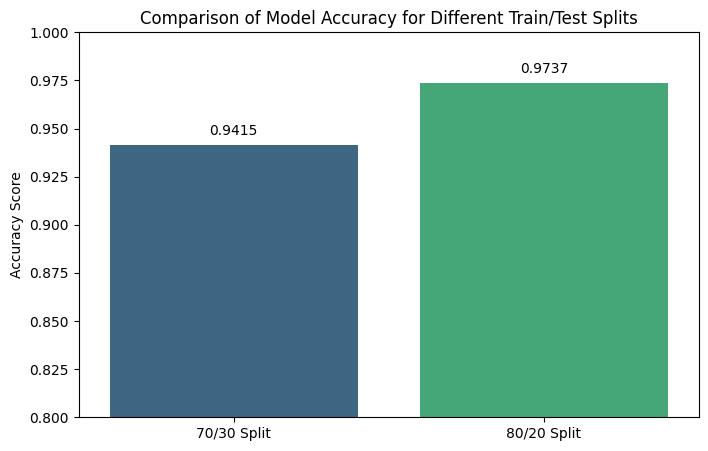

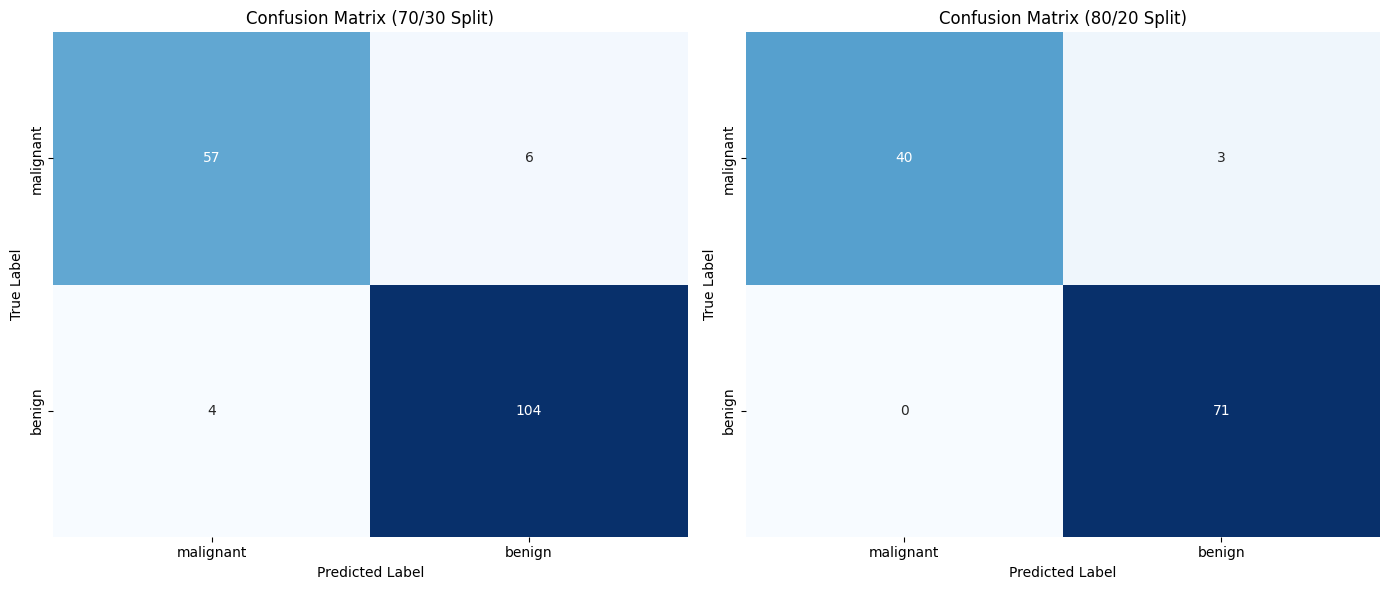

Accuracy and Confusion Matrix plots generated for comparison.


In [7]:
print("Visualizing comparison of model performance...")

# 1. Compare Accuracy Scores
accuracy_scores = [accuracy_70, accuracy_80]
split_ratios = ['70/30 Split', '80/20 Split']

plt.figure(figsize=(8, 5))
sns.barplot(x=split_ratios, y=accuracy_scores, hue=split_ratios, palette='viridis', legend=False)
plt.title('Comparison of Model Accuracy for Different Train/Test Splits')
plt.ylabel('Accuracy Score')
plt.ylim(0.8, 1.0) # Set y-axis limit for better comparison
for index, value in enumerate(accuracy_scores):
    plt.text(index, value + 0.005, f'{value:.4f}', ha='center')
plt.show()

# 2. Compare Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(conf_matrix_70, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=cancer.target_names, yticklabels=cancer.target_names, ax=axes[0])
axes[0].set_title('Confusion Matrix (70/30 Split)')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

sns.heatmap(conf_matrix_80, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=cancer.target_names, yticklabels=cancer.target_names, ax=axes[1])
axes[1].set_title('Confusion Matrix (80/20 Split)')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

print("Accuracy and Confusion Matrix plots generated for comparison.")

Libraries imported and Breast Cancer dataset loaded successfully.
Shape of the DataFrame:
(569, 31)


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error 

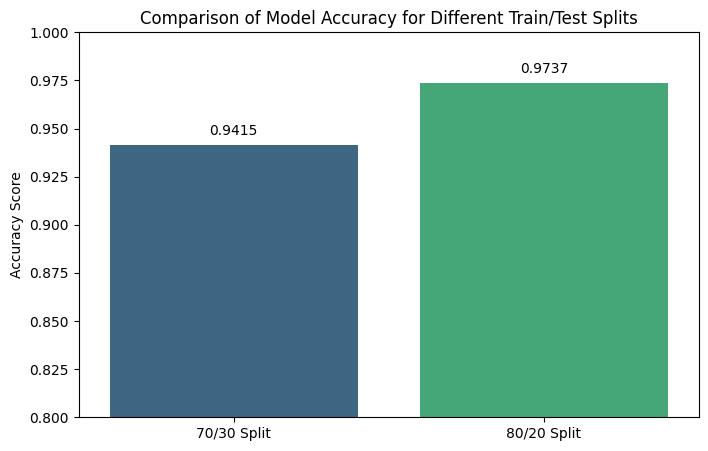

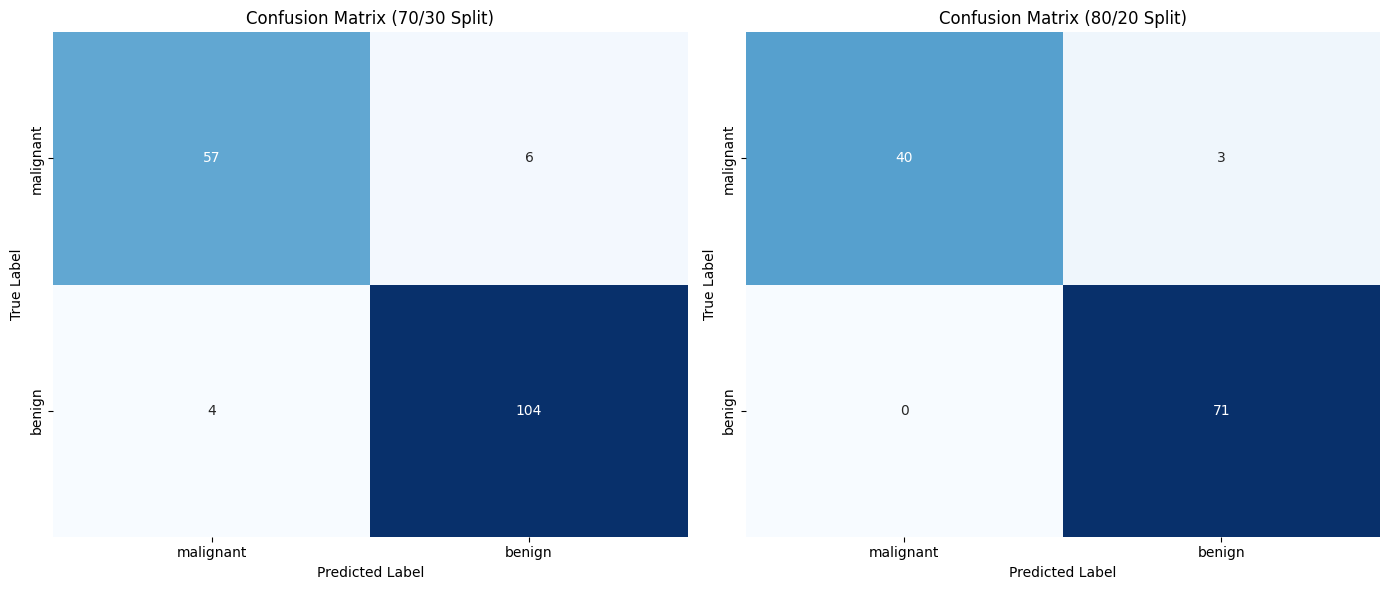

Accuracy and Confusion Matrix plots generated for comparison.


In [8]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load the Breast Cancer dataset
cancer = load_breast_cancer()

print("Libraries imported and Breast Cancer dataset loaded successfully.")

# Convert to DataFrame and Basic Data Analysis
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target

print("Shape of the DataFrame:")
print(df.shape)
print("\n")

print("DataFrame Info:")
df.info()
print("\n")

print("Descriptive Statistics:")
print(df.describe())
print("\n")

print("Missing Values:")
print(df.isnull().sum())
print("\n")

print("Target Variable Class Distribution:")
print(df['target'].value_counts())

# Split Dataset for Training and Testing
X = df.drop('target', axis=1)
y = df['target']

# Split 1: 70% training / 30% testing
X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(X, y, test_size=0.3, random_state=42)

# Split 2: 80% training / 20% testing
X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nDataset split into features (X) and target (y).")
print(f"Shape of X: {X.shape}, Shape of y: {y.shape}\n")

print("70/30 Split Shapes:")
print(f"X_train_70: {X_train_70.shape}, X_test_70: {X_test_70.shape}")
print(f"y_train_70: {y_train_70.shape}, y_test_70: {y_test_70.shape}\n")

print("80/20 Split Shapes:")
print(f"X_train_80: {X_train_80.shape}, X_test_80: {X_test_80.shape}")
print(f"y_train_80: {y_train_80.shape}, y_test_80: {y_test_80.shape}")

# Train Gaussian Naive Bayes Model
model_70 = GaussianNB()
model_80 = GaussianNB()

# Train model on 70/30 split
model_70.fit(X_train_70, y_train_70)
print("\nGaussian Naive Bayes model trained on 70/30 split.")

# Train model on 80/20 split
model_80.fit(X_train_80, y_train_80)
print("Gaussian Naive Bayes model trained on 80/20 split.")

# Model Evaluation
print("\nEvaluation for 70/30 Split:")
# Make predictions
y_pred_70 = model_70.predict(X_test_70)

# Calculate accuracy
accuracy_70 = accuracy_score(y_test_70, y_pred_70)
print(f"Accuracy: {accuracy_70:.4f}")

# Generate confusion matrix
conf_matrix_70 = confusion_matrix(y_test_70, y_pred_70)
print("Confusion Matrix:")
print(conf_matrix_70)

# Generate classification report
class_report_70 = classification_report(y_test_70, y_pred_70)
print("Classification Report:")
print(class_report_70)

print("\n" + "-"*30 + "\n")

print("Evaluation for 80/20 Split:")
# Make predictions
y_pred_80 = model_80.predict(X_test_80)

# Calculate accuracy
accuracy_80 = accuracy_score(y_test_80, y_pred_80)
print(f"Accuracy: {accuracy_80:.4f}")

# Generate confusion matrix
conf_matrix_80 = confusion_matrix(y_test_80, y_pred_80)
print("Confusion Matrix:")
print(conf_matrix_80)

# Generate classification report
class_report_80 = classification_report(y_test_80, y_pred_80)
print("Classification Report:")
print(class_report_80)

# Compare Results with Visualizations
print("\nVisualizing comparison of model performance...")

# 1. Compare Accuracy Scores
accuracy_scores = [accuracy_70, accuracy_80]
split_ratios = ['70/30 Split', '80/20 Split']

plt.figure(figsize=(8, 5))
sns.barplot(x=split_ratios, y=accuracy_scores, hue=split_ratios, palette='viridis', legend=False)
plt.title('Comparison of Model Accuracy for Different Train/Test Splits')
plt.ylabel('Accuracy Score')
plt.ylim(0.8, 1.0) # Set y-axis limit for better comparison
for index, value in enumerate(accuracy_scores):
    plt.text(index, value + 0.005, f'{value:.4f}', ha='center')
plt.show()

# 2. Compare Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(conf_matrix_70, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=cancer.target_names, yticklabels=cancer.target_names, ax=axes[0])
axes[0].set_title('Confusion Matrix (70/30 Split)')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

sns.heatmap(conf_matrix_80, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=cancer.target_names, yticklabels=cancer.target_names, ax=axes[1])
axes[1].set_title('Confusion Matrix (80/20 Split)')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

print("Accuracy and Confusion Matrix plots generated for comparison.")
